In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import polars as pl
import adbc_driver_postgresql.dbapi as dbapi

with dbapi.connect("host=dell1 port=5432 dbname=bingo user=tokeiya3") as conn:
    df = pl.read_database("""
                          SELECT round, hit_count, COUNT(*) AS cnt
                          FROM all_cards
                          WHERE cards = 100
                          GROUP BY round, hit_count
                          ORDER BY round, hit_count
                          """, connection=conn)


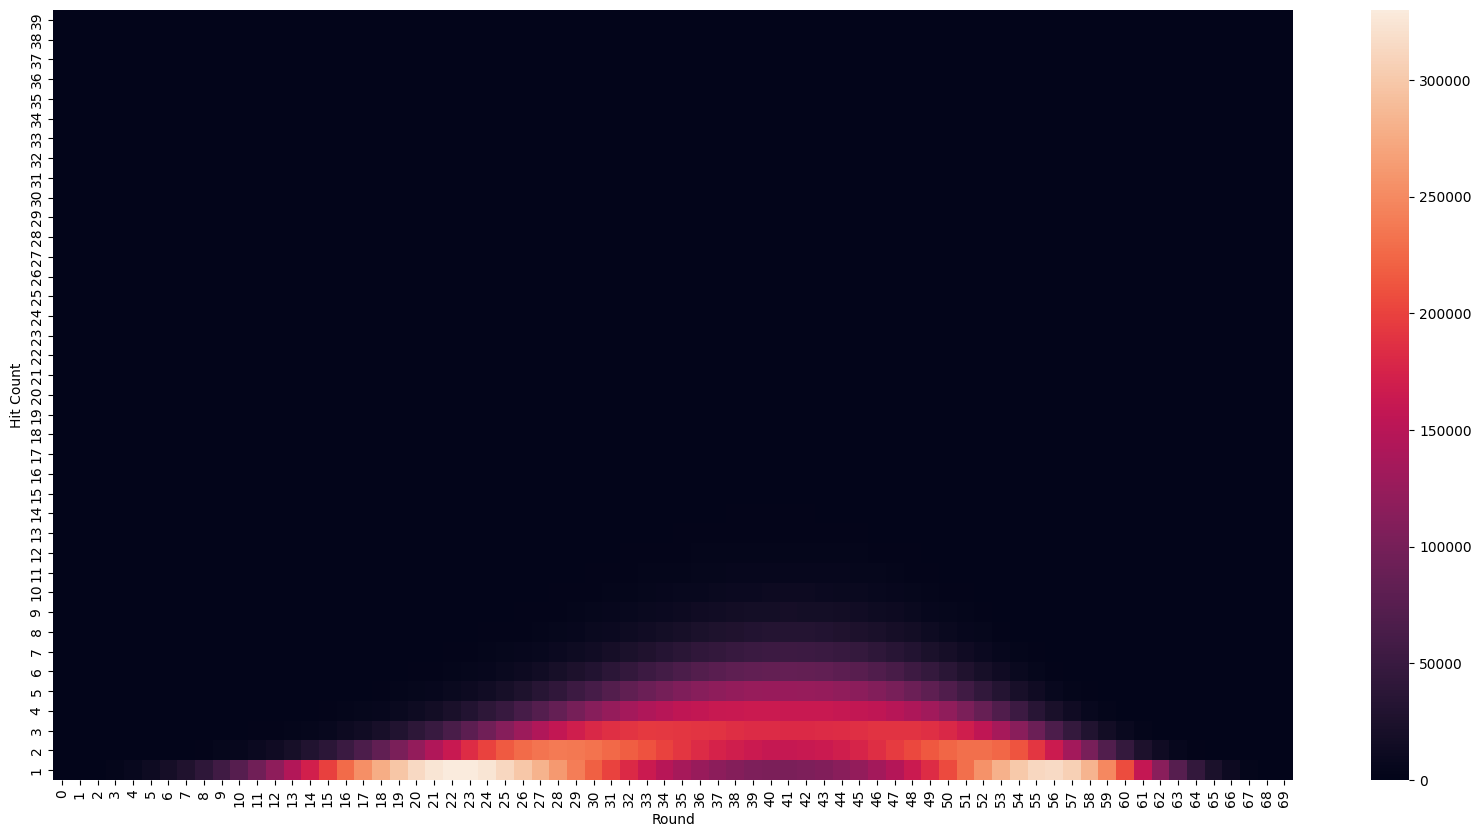

In [19]:
hdf = df.pivot(index="hit_count", on="round", values="cnt", aggregate_function="sum").fill_null(0).sort('hit_count')
hdf = hdf.filter(pl.col('hit_count') > 0)
plt.figure(figsize=(20, 10), dpi=100)

ax = sns.heatmap(hdf, yticklabels=hdf['hit_count'].to_list())
ax.set_xlabel("Round")
ax.set_ylabel("Hit Count")
ax.invert_yaxis()


In [12]:
hdf

hit_count,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72
i32,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
1,170,815,1999,3929,7145,11425,17527,25578,35378,47629,62151,78408,97661,117771,141042,164479,188684,214040,237977,259900,281738,300328,316022,327102,334782,338521,337527,333590,328384,319899,309129,298618,286825,275244,263904,254463,245741,238776,234072,230236,230528,231096,234704,240840,248483,258070,269471,282543,295437,309304,320387,326867,330173,325366,313793,292505,264232,228813,188943,148461,109353,75552,48031,27721,14475,6562,2241,586,76
2,2,6,28,63,149,314,584,960,1668,2678,4073,6288,9100,12851,17800,24033,31958,41316,53042,66488,81075,96616,113924,131716,149300,166186,183157,197711,211124,221307,229621,236843,241168,242723,244154,244577,244128,242685,241629,241684,240794,240650,241142,241508,241300,241576,241335,237064,232121,223218,211564,194509,173946,150728,124513,98168,73560,51961,33355,20101,10843,5281,2323,872,303,67,7,0,0
3,0,0,0,4,7,26,39,72,151,264,402,732,1096,1566,2496,3730,5370,7590,10534,14480,19243,25465,32677,41246,51220,62575,74282,86813,99753,111874,124699,135020,146281,154642,161799,168079,173120,176780,178508,180198,180189,179736,177634,174871,170049,163859,156314,145776,134146,119255,103460,86789,69488,53145,38351,25918,15915,9167,4696,2127,847,318,103,23,3,0,0,0,0
4,0,0,0,0,0,1,6,8,17,41,68,109,189,322,468,768,1063,1531,2394,3427,4702,6462,8892,12155,16042,20584,26096,32583,39663,47474,55664,63421,71359,79390,86920,92879,98543,103098,106601,107914,108614,107921,106046,101956,97404,90159,82463,73741,63541,53311,42314,32689,23643,15819,10045,5852,3047,1417,562,207,69,10,1,0,0,0,0,0,0
5,0,0,0,0,0,0,0,3,5,7,18,19,35,81,108,179,272,435,637,922,1324,1961,2727,3718,5127,6831,8973,11646,14698,18491,22469,26842,31623,36337,40905,45151,48883,51980,55020,55952,56384,55912,54055,51563,48134,43866,38400,32865,27101,20854,15519,10995,7381,4442,2478,1192,518,209,71,14,7,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,1,0,0,3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
22,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
23,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
